# 📊 Spam Message Collector — Gün 1: Keşifsel Veri Analizi (EDA)

> **Amaç:** Ham veri setini yüklemek, kalitesini değerlendirmek ve spam/ham mesajların temel istatistiksel özelliklerini görsel olarak keşfetmek.

**Veri Kaynağı:** UCI SMS Spam Collection Dataset (Kaggle)
**Tarih:** 2026-07-24

---
## Hücre 1: Kütüphaneleri İçe Aktarma

In [1]:
# --- Temel kütüphaneler ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Görselleştirme kütüphaneleri ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Notebook içinde grafiklerin görünmesi için
%matplotlib inline

# --- Görsel stil ayarları ---
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

print("✅ Tüm kütüphaneler başarıyla yüklendi.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi.
   pandas  : 3.0.5
   numpy   : 2.5.1
   seaborn : 0.13.2


---
## Hücre 2: Ham Veriyi Yükleme ve İlk Bakış

In [2]:
# --- Dosya yolunu projeye göre dinamik olarak belirle ---
# Bu notebook 'notebooks/' klasöründe çalıştığı için bir üst dizine çıkıyoruz.
PROJECT_ROOT = Path("../")
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "spam.csv"

print(f"📂 Veri dosyası aranıyor: {DATA_PATH.resolve()}")

# --- Veriyi yükle ---
# Not: Kaggle'dan gelen bu veri seti latin-1 (ISO-8859-1) encoding ile kodlanmıştır.
# Buna dikkat etmezsek UnicodeDecodeError hatası alırız.
# Gereksiz boş sütunları ('Unnamed') dışarıda bırakmak için usecols kullanıyoruz.
df_raw = pd.read_csv(
    DATA_PATH,
    encoding="latin-1",
    usecols=[0, 1],           # Sadece ilk 2 sütunu al (v1, v2)
    names=["label", "message"],  # Sütunları anlamlı isimlerle yeniden adlandır
    header=0                  # İlk satır header, okurken atla
)

print(f"\n✅ Veri başarıyla yüklendi!")
print(f"   Boyut: {df_raw.shape[0]} satır × {df_raw.shape[1]} sütun")

# --- İlk birkaç satıra bak ---
print("\n📋 İlk 5 Satır:")
df_raw.head()

📂 Veri dosyası aranıyor: /Users/semikzr/PycharmProjects/spam-message-collector/data/raw/spam.csv

✅ Veri başarıyla yüklendi!
   Boyut: 5572 satır × 2 sütun

📋 İlk 5 Satır:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


---
## Hücre 3: Veri Kalitesi Kontrolü (Eksik ve Tekrarlayan Değerler)

In [3]:
print("=" * 55)
print(" VERİ KALİTESİ RAPORU ")
print("=" * 55)

# --- 1. Veri Tipleri ---
print("\n📌 Sütun Veri Tipleri:")
print(df_raw.dtypes)

# --- 2. Eksik Değer Analizi ---
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({"Eksik Sayısı": missing, "Yüzdesi (%)": missing_pct})

print("\n🔍 Eksik (NaN) Değer Analizi:")
print(missing_report)

if missing.sum() == 0:
    print("   → Eksik değer bulunamadı. ✅")
else:
    print(f"   → Toplam {missing.sum()} eksik değer tespit edildi. Temizlenecek!")

# --- 3. Tekrarlayan Değer Analizi ---
n_duplicates = df_raw.duplicated().sum()
print(f"\n🔍 Tekrarlayan (Duplicate) Satır Sayısı: {n_duplicates}")

if n_duplicates > 0:
    print("   → Tekrarlayan satırlar aşağıda gösterilmektedir:")
    display(df_raw[df_raw.duplicated(keep=False)].sort_values("message").head(10))
else:
    print("   → Tekrarlayan satır bulunamadı. ✅")

 VERİ KALİTESİ RAPORU 

📌 Sütun Veri Tipleri:
label      str
message    str
dtype: object

🔍 Eksik (NaN) Değer Analizi:
         Eksik Sayısı  Yüzdesi (%)
label               0          0.0
message             0          0.0
   → Eksik değer bulunamadı. ✅

🔍 Tekrarlayan (Duplicate) Satır Sayısı: 403
   → Tekrarlayan satırlar aşağıda gösterilmektedir:


,label,message
504,spam,+123 Congratulations - in this week's competit...
2123,spam,+123 Congratulations - in this week's competit...
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1372,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2162,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1049,spam,18 days to Euro2004 kickoff! U will be kept in...
2718,spam,18 days to Euro2004 kickoff! U will be kept in...
2043,spam,4mths half price Orange line rental & latest c...
388,spam,4mths half price Orange line rental & latest c...
1778,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...


---
## Hücre 4: Veri Temizleme

In [4]:
print(f"Temizlik öncesi veri boyutu : {df_raw.shape}")

# --- Veri setinin bir kopyası üzerinde çalışıyoruz (ham veri bozulmasın) ---
df = df_raw.copy()

# --- Adım 1: Eksik değerlerin olduğu satırları sil ---
df.dropna(inplace=True)

# --- Adım 2: Tekrarlayan satırları sil (ilk görüneni koru) ---
df.drop_duplicates(inplace=True)

# --- Adım 3: Indeksi sıfırla ---
df.reset_index(drop=True, inplace=True)

print(f"Temizlik sonrası veri boyutu: {df.shape}")
print(f"\n✅ Toplam {df_raw.shape[0] - df.shape[0]} satır temizlendi.")

# --- Etiket dağılımını göster ---
print("\n📊 Etiket Dağılımı:")
print(df["label"].value_counts())
print(f"\nSpam Oranı : {df['label'].value_counts(normalize=True)['spam']*100:.2f}%")
print(f"Ham Oranı  : {df['label'].value_counts(normalize=True)['ham']*100:.2f}%")

Temizlik öncesi veri boyutu : (5572, 2)
Temizlik sonrası veri boyutu: (5169, 2)

✅ Toplam 403 satır temizlendi.

📊 Etiket Dağılımı:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam Oranı : 12.63%
Ham Oranı  : 87.37%


---
## Hücre 5: Görselleştirme 1 — Spam/Ham Sınıf Dağılımı

/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/2895192333.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/2895192333.py:53: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig("../data/processed/eda_class_distribution.png", bbox_inches="tight", dpi=150)
/Users/semikzr/PycharmProjects/spam-message-collector/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


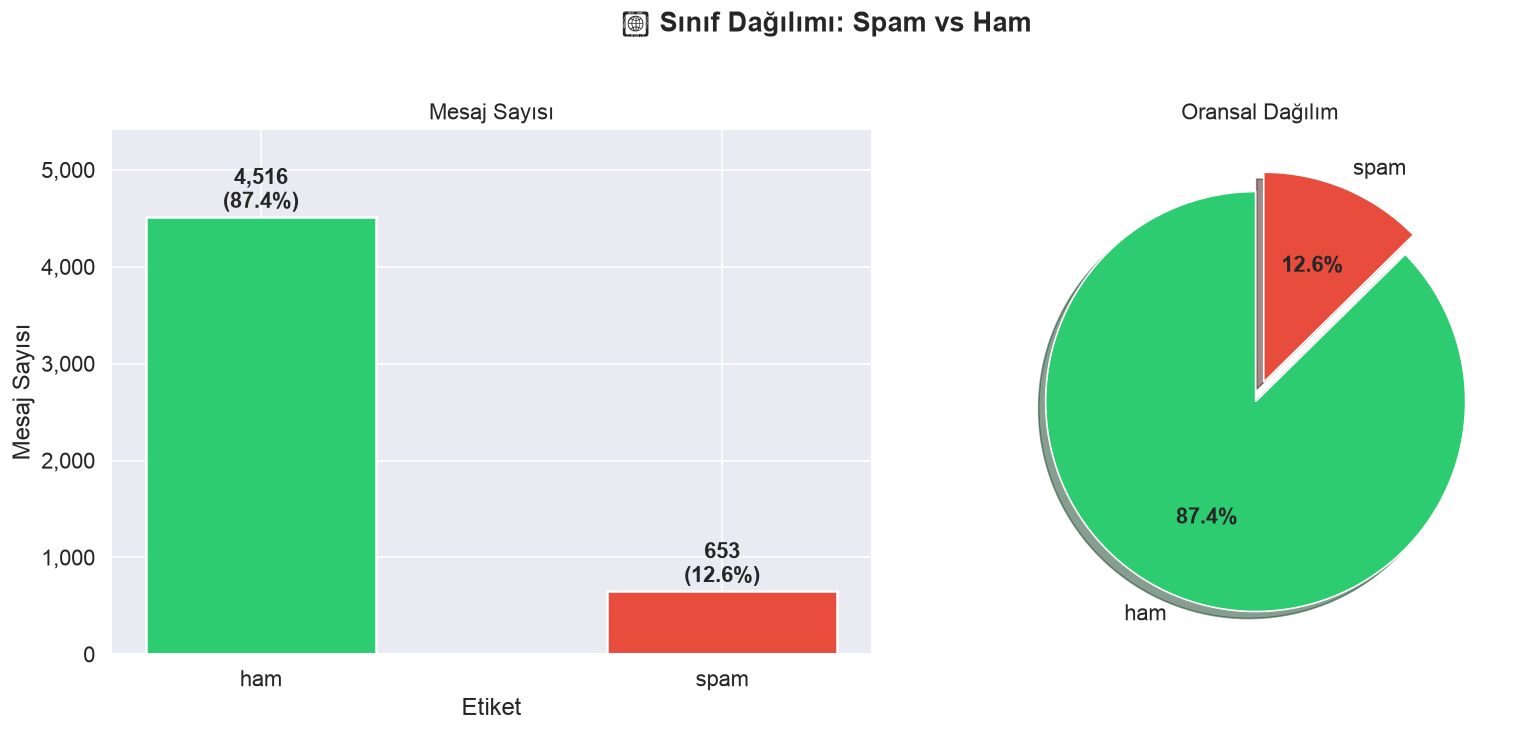


💡 Not: Veri seti belirgin biçimde dengesiz! Ham mesajlar spama göre ~6.5x daha fazla.
   Model eğitiminde class_weight='balanced' veya oversampling tekniklerini düşünmeliyiz.


In [5]:
# --- Renk paleti ---
COLORS = {"ham": "#2ecc71", "spam": "#e74c3c"}
label_counts = df["label"].value_counts()
label_pcts = df["label"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("📊 Sınıf Dağılımı: Spam vs Ham", fontsize=16, fontweight="bold", y=1.02)

# --- Sol: Bar Grafiği ---
ax1 = axes[0]
bars = ax1.bar(
    label_counts.index,
    label_counts.values,
    color=[COLORS[l] for l in label_counts.index],
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)

# Bar'ların üstüne sayı ve yüzde ekle
for bar, (label, count) in zip(bars, label_counts.items()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({label_pcts[label]:.1f}%)",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax1.set_title("Mesaj Sayısı", fontsize=13)
ax1.set_xlabel("Etiket")
ax1.set_ylabel("Mesaj Sayısı")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.set_ylim(0, label_counts.max() * 1.2)

# --- Sağ: Pasta Grafiği ---
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    colors=[COLORS[l] for l in label_counts.index],
    startangle=90,
    explode=[0.05, 0.05],
    shadow=True,
    textprops={"fontsize": 13}
)
for at in autotexts:
    at.set_fontweight("bold")

ax2.set_title("Oransal Dağılım", fontsize=13)

plt.tight_layout()
plt.savefig("../data/processed/eda_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n💡 Not: Veri seti belirgin biçimde dengesiz! Ham mesajlar spama göre ~6.5x daha fazla.")
print("   Model eğitiminde class_weight='balanced' veya oversampling tekniklerini düşünmeliyiz.")

---
## Hücre 6: Özellik Mühendisliği — Karakter Uzunluğu Sütunu

In [6]:
# --- Mesajların karakter ve kelime sayısını hesapla ---
df["char_count"] = df["message"].str.len()
df["word_count"] = df["message"].str.split().str.len()

print("✅ 'char_count' ve 'word_count' sütunları eklendi.")
print("\n📋 Güncellenen Veri Seti (ilk 5 satır):")
display(df.head())

# --- Grup bazında özet istatistikler ---
print("\n📊 Etiket Bazında Karakter Uzunluğu İstatistikleri:")
display(
    df.groupby("label")[["char_count", "word_count"]]
    .describe()
    .round(2)
    .style.background_gradient(cmap="RdYlGn_r")
)

✅ 'char_count' ve 'word_count' sütunları eklendi.

📋 Güncellenen Veri Seti (ilk 5 satır):


,label,message,char_count,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13



📊 Etiket Bazında Karakter Uzunluğu İstatistikleri:


---
## Hücre 7: Görselleştirme 2 — Karakter Uzunluğu Dağılım Karşılaştırması

/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/3277902814.py:44: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/3277902814.py:45: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.savefig("../data/processed/eda_char_length_distribution.png", bbox_inches="tight", dpi=150)
/Users/semikzr/PycharmProjects/spam-message-collector/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


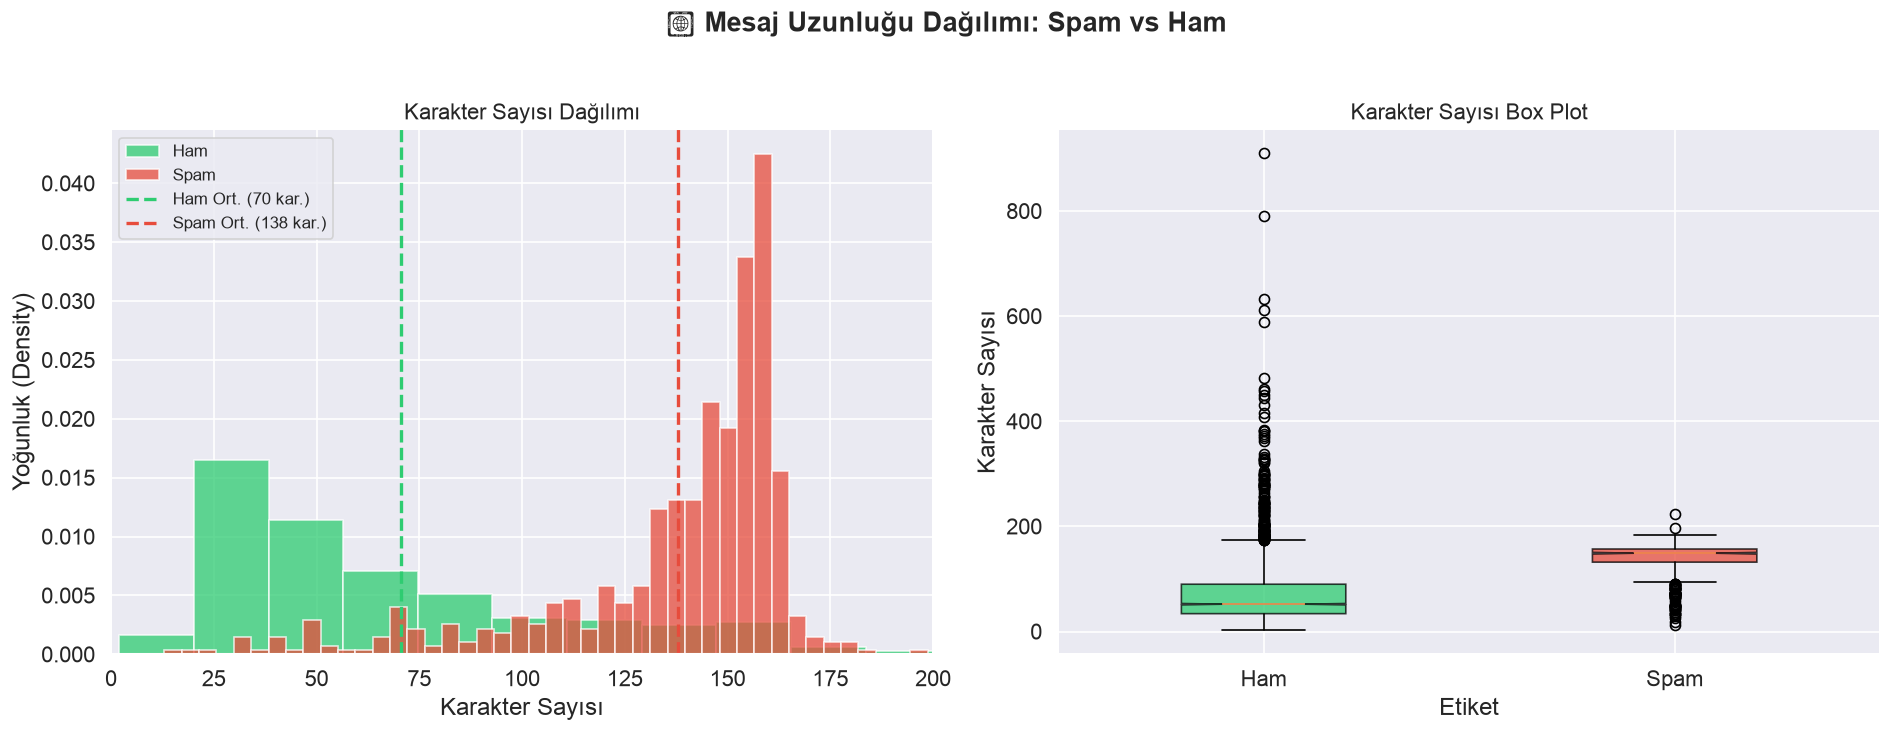


💡 Gözlem:
   Ham mesajların ortalama uzunluğu  : 70.5 karakter
   Spam mesajların ortalama uzunluğu : 137.9 karakter
   → Spam mesajlar genellikle HAM mesajlara göre çok daha uzundur.
   → 'char_count' özelliği modele güçlü bir sinyal sağlayabilir!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("📏 Mesaj Uzunluğu Dağılımı: Spam vs Ham", fontsize=16, fontweight="bold", y=1.02)

ham_data = df[df["label"] == "ham"]
spam_data = df[df["label"] == "spam"]

# --- Sol: Karakter Uzunluğu Histogramı ---
ax1 = axes[0]
ax1.hist(ham_data["char_count"], bins=50, color=COLORS["ham"], alpha=0.75, label="Ham", density=True)
ax1.hist(spam_data["char_count"], bins=50, color=COLORS["spam"], alpha=0.75, label="Spam", density=True)

# Ortalama dikey çizgileri ekle
ax1.axvline(ham_data["char_count"].mean(), color=COLORS["ham"], linestyle="--", lw=2,
            label=f"Ham Ort. ({ham_data['char_count'].mean():.0f} kar.)")
ax1.axvline(spam_data["char_count"].mean(), color=COLORS["spam"], linestyle="--", lw=2,
            label=f"Spam Ort. ({spam_data['char_count'].mean():.0f} kar.)")

ax1.set_title("Karakter Sayısı Dağılımı", fontsize=13)
ax1.set_xlabel("Karakter Sayısı")
ax1.set_ylabel("Yoğunluk (Density)")
ax1.legend(fontsize=10)
ax1.set_xlim(0, 200)   # Odaklanmak için sınır

# --- Sağ: Box Plot karşılaştırması ---
# Not: Matplotlib 3.11+ sürümünde "labels" parametresi "tick_labels" olarak yeniden adlandırıldı
ax2 = axes[1]
bp = ax2.boxplot(
    [ham_data["char_count"].values, spam_data["char_count"].values],
    tick_labels=["Ham", "Spam"],  # matplotlib 3.11+ için güncellendi (eskisi: labels=)
    patch_artist=True,
    notch=True,
    widths=0.4
)

# Box Plot renklendirme
for patch, color in zip(bp["boxes"], [COLORS["ham"], COLORS["spam"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_title("Karakter Sayısı Box Plot", fontsize=13)
ax2.set_xlabel("Etiket")
ax2.set_ylabel("Karakter Sayısı")

plt.tight_layout()
plt.savefig("../data/processed/eda_char_length_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("\n💡 Gözlem:")
print(f"   Ham mesajların ortalama uzunluğu  : {ham_data['char_count'].mean():.1f} karakter")
print(f"   Spam mesajların ortalama uzunluğu : {spam_data['char_count'].mean():.1f} karakter")
print("   → Spam mesajlar genellikle HAM mesajlara göre çok daha uzundur.")
print("   → 'char_count' özelliği modele güçlü bir sinyal sağlayabilir!")


---
## Hücre 8: Bonus — Kelime Uzunluğu Karşılaştırması (KDE Plot)

/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/142358998.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Etiket")
/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/142358998.py:15: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/v4/dvg2_6dj5dq2r2y_8mwkwvm00000gn/T/ipykernel_51828/142358998.py:16: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  plt.savefig("../data/processed/eda_word_count_kde.png", bbox_inches="tight", dpi=150)
/Users/semikzr/PycharmProjects/spam-message-collector/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


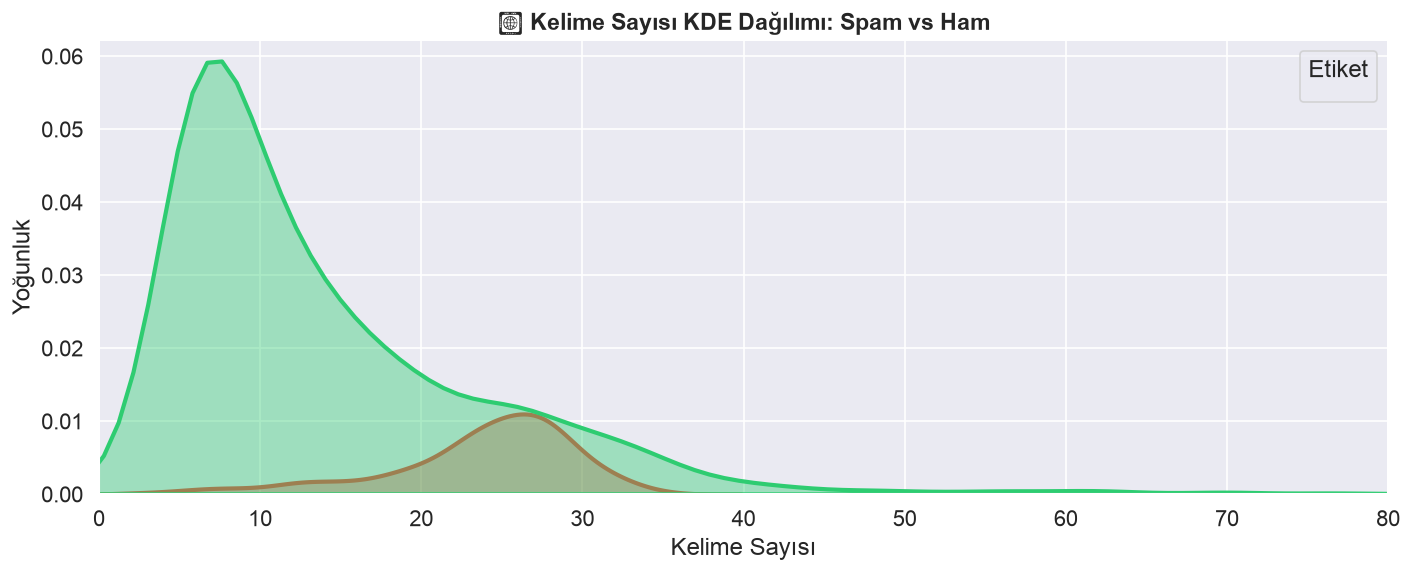

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

# KDE (Kernel Density Estimate) plotlar çok daha pürüzsüz dağılım gösterir
sns.kdeplot(data=df, x="word_count", hue="label",
            fill=True, alpha=0.4, linewidth=2.5,
            palette={"ham": COLORS["ham"], "spam": COLORS["spam"]},
            ax=ax)

ax.set_title("📝 Kelime Sayısı KDE Dağılımı: Spam vs Ham", fontsize=14, fontweight="bold")
ax.set_xlabel("Kelime Sayısı")
ax.set_ylabel("Yoğunluk")
ax.set_xlim(0, 80)
ax.legend(title="Etiket")

plt.tight_layout()
plt.savefig("../data/processed/eda_word_count_kde.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Hücre 9: EDA Özeti ve Sonraki Adımlar

In [9]:
print("=" * 60)
print(" GÜN 1 — EDA ÖZET RAPORU ")
print("=" * 60)
print(f"\n📦 Toplam Veri Sayısı  : {len(df):,} mesaj")
print(f"   Ham (Normal) Mesaj : {(df['label']=='ham').sum():,} ({(df['label']=='ham').mean()*100:.1f}%)")
print(f"   Spam Mesaj         : {(df['label']=='spam').sum():,} ({(df['label']=='spam').mean()*100:.1f}%)")
print(f"\n📏 Karakter Uzunluğu:")
print(f"   Ham  — Ort: {ham_data['char_count'].mean():.1f} | Medyan: {ham_data['char_count'].median():.0f} | Maks: {ham_data['char_count'].max()}")
print(f"   Spam — Ort: {spam_data['char_count'].mean():.1f} | Medyan: {spam_data['char_count'].median():.0f} | Maks: {spam_data['char_count'].max()}")

print("\n🔮 Sonraki Adımlar (Gün 2: NLP Preprocessing):")
print("   1. Metinleri küçük harfe çevirme (lowercasing)")
print("   2. Noktalama işaretlerini ve sayıları kaldırma")
print("   3. Stop-word'leri NLTK ile kaldırma")
print("   4. Lemmatization (WordNetLemmatizer)")
print("   5. TF-IDF vektörizasyonu")
print("   6. Temizlenmiş veriyi data/processed/cleaned_data.csv'ye kaydetme")

 GÜN 1 — EDA ÖZET RAPORU 

📦 Toplam Veri Sayısı  : 5,169 mesaj
   Ham (Normal) Mesaj : 4,516 (87.4%)
   Spam Mesaj         : 653 (12.6%)

📏 Karakter Uzunluğu:
   Ham  — Ort: 70.5 | Medyan: 52 | Maks: 910
   Spam — Ort: 137.9 | Medyan: 149 | Maks: 224

🔮 Sonraki Adımlar (Gün 2: NLP Preprocessing):
   1. Metinleri küçük harfe çevirme (lowercasing)
   2. Noktalama işaretlerini ve sayıları kaldırma
   3. Stop-word'leri NLTK ile kaldırma
   4. Lemmatization (WordNetLemmatizer)
   5. TF-IDF vektörizasyonu
   6. Temizlenmiş veriyi data/processed/cleaned_data.csv'ye kaydetme
